In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import torch
import argparse
import yaml
from numba import cuda
import zuko
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from helpers.models.DNN import count_parameters
from helpers.evaluation import get_kl_dist, discriminate_data_from_samples

plt.style.use("../science.mplstyle")

In [2]:
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d

In [3]:


BIN_BOUND = 5
NUM_BINS = 100
NUM_FEATURES = 5

ZUKO_ID = "CNF"
SEED = 8
BATCH_SIZE = 256
NUM_COND_INPUTS = 0



In [4]:
save_dir = f"outputs/{ZUKO_ID}"
os.makedirs(save_dir, exist_ok=True)

In [5]:

# computing
device = cuda.get_current_device()
device.reset()
torch.set_num_threads(2)
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)
seed = int(SEED)
torch.manual_seed(seed)
np.random.seed(seed)

Using device: cuda


In [6]:
collections_TrackerHitPlane = [
    "IBTrackerHits",
    "IBTrackerHitsConed",
    "IETrackerHits", 
    "IETrackerHitsConed",
    "OBTrackerHits",
    "OBTrackerHitsConed", 
    "OETrackerHits",        
    "OETrackerHitsConed",          
    "VBTrackerHits",               
    "VBTrackerHitsConed",   
    "VETrackerHits",  
    "VETrackerHitsConed",        
]

collections_SimTrackerHit = [
  #  "InnerTrackerBarrelCollection",
   # "InnerTrackerBarrelCollectionConed",
 #   "InnerTrackerEndcapCollection",
    #"InnerTrackerEndcapCollectionConed", 
    "OuterTrackerBarrelCollection",     
   # "OuterTrackerBarrelCollectionConed",
 #   "OuterTrackerEndcapCollection",  
   # "OuterTrackerEndcapCollectionConed",
 #   "VertexBarrelCollection",   
   # "VertexBarrelCollectionConed",   
  #  "VertexEndcapCollection",
   # "VertexEndcapCollectionConed",
]



feature_labels = ["log($E$) [Gev]", "$x$", "$y$", "$z$", "$t$ [s]", "context"]
log_vars = []

In [7]:

data = []
context = []

for i, collection in enumerate(collections_SimTrackerHit): # TODO coned too?

    tmp_data = np.load(f"/pscratch/sd/r/rmastand/muon/npys/{collection}_SimTrackerHit.npy")
    tmp_context = int(i)*np.ones((tmp_data.shape[0],1))
    context.append(tmp_context)
    data.append(tmp_data[:int(len(tmp_data)*.1)])


data = np.vstack(data)[:,[0,2,3,4,5]]
#data = data[data[:,0] > 2e-6]
data[:,0] = np.log(data[:,0])
context = np.vstack(context)

bins_dict = {}
bins_dict_preproc = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(data.shape[1])}

for i in range(data.shape[1]):
    if i in log_vars:
        bins_dict[i] = np.logspace(np.log10(0.9*np.min(data[:,i])), np.log10(1.1*np.max(data[:,i])), NUM_BINS) 
    else:
        bins_dict[i] = np.linspace(np.min(data[:,i] - 3), np.max(data[:,i] + 3), NUM_BINS) 

In [8]:

def preprocess_data(X, flow_training_dir):
    """
    Preprocess data without modifying the original array.
    Applies log to the first column and standardizes all columns.
    """

    if ZUKO_ID in ["UNAF", "NCSF"]:
        min_max_scaler = MinMaxScaler(feature_range=(-3,3))
        X_preproc = min_max_scaler.fit_transform(X)
        with open(f"{flow_training_dir}/minmax", "wb") as ofile:
            pickle.dump(min_max_scaler, ofile)


    else:
        standard_scaler = StandardScaler()
        X_preproc = standard_scaler.fit_transform(X)
        with open(f"{flow_training_dir}/standard", "wb") as ofile:
            pickle.dump(standard_scaler, ofile)
    

    return X_preproc


def inverse_preprocess_data(X_preproc, flow_training_dir,):
    """
    Inverse preprocessing without modifying the input array.
    Inverts standardization and applies exp to the first column.
    """
    # load scaler
    if ZUKO_ID in ["UNAF", "NCSF"]:
        with open(f"{flow_training_dir}/minmax", "rb") as ifile:
            min_max_scaler = pickle.load(ifile)
        X = min_max_scaler.inverse_transform(X_preproc)

    else:
        with open(f"{flow_training_dir}/standard", "rb") as ifile:
            standard_scaler = pickle.load(ifile)
        X = standard_scaler.inverse_transform(X_preproc)
        
    

    return X

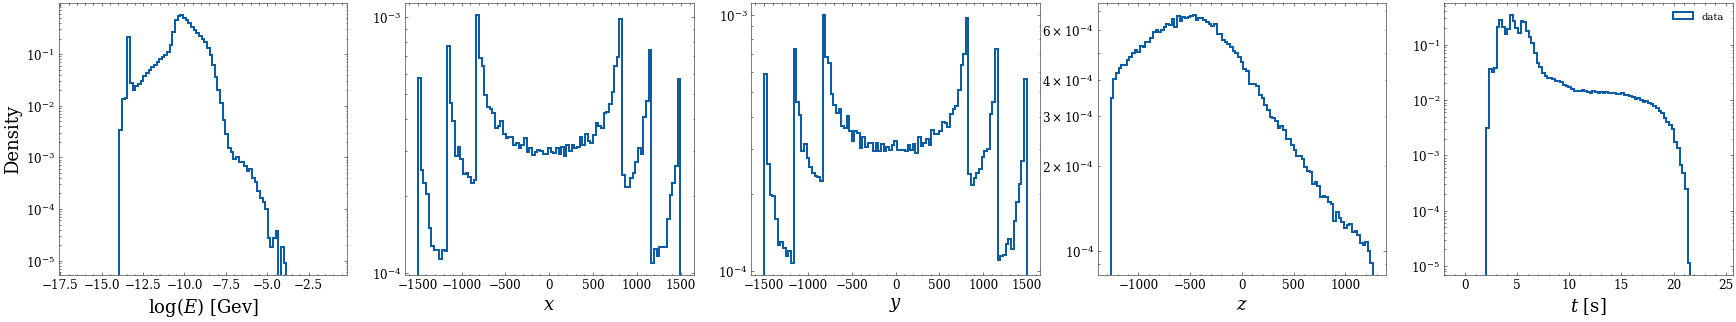

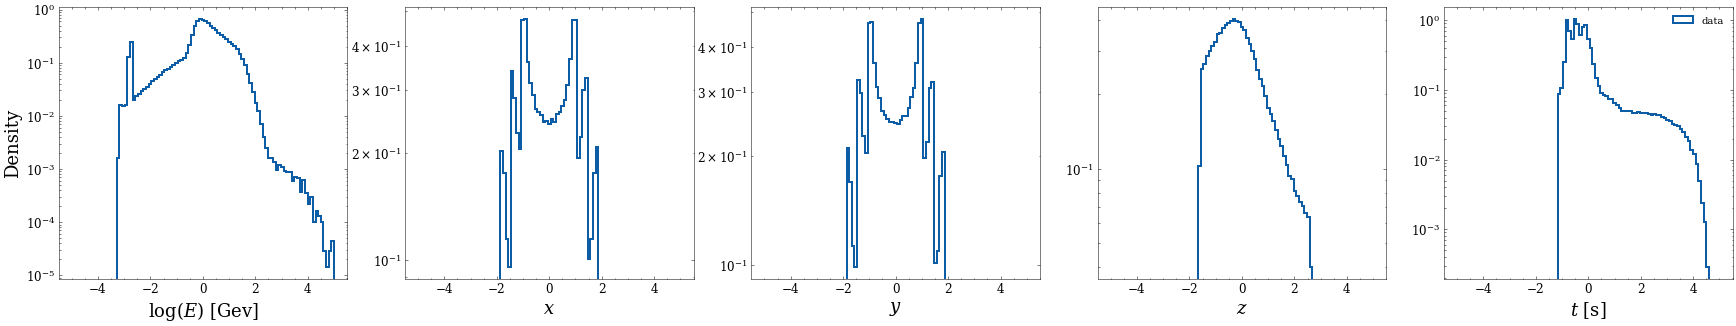

In [9]:


X_preproc = preprocess_data(data, ".")
if NUM_COND_INPUTS == 1:
    X_preproc = np.hstack([X_preproc,  context])
elif NUM_COND_INPUTS == 0:
    pass
else:
    print("ERROR")
    exit()


plot_hists_1d({"data":data}, bins_dict, log_dims=log_vars, labels=feature_labels)
plt.show()

plot_hists_1d({"data":X_preproc}, bins_dict_preproc, log_dims=[], labels = feature_labels)
plt.show()

In [10]:
# train val split
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(X_preproc, test_size=0.2, random_state=42)

print(f"Train data has shape {data_train.shape}.")
print(f"Val data has shape {data_val.shape}.")


train_loader = torch.utils.data.DataLoader(data_train, batch_size=BATCH_SIZE, shuffle=True, num_workers = 8, pin_memory = True)
val_loader = torch.utils.data.DataLoader(data_val, batch_size=BATCH_SIZE, shuffle=False, num_workers = 8, pin_memory = True)

Train data has shape (543000, 5).
Val data has shape (135750, 5).


In [11]:
import zuko

# Neural spline flow (NSF) with 3 sample features and 5 context features

if ZUKO_ID == "NSF":
    flow = zuko.flows.NSF(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
#elif ZUKO_ID == "GMM":
#    flow = zuko.flows.GMM(5, 0, components=30, hidden_features=[256] * 5).to(device)
elif ZUKO_ID == "NICE":
    flow = zuko.flows.NICE(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif ZUKO_ID == "MAF":
    flow = zuko.flows.MAF(5, 0, transforms=4, hidden_features=[256] * 3).to(device)
elif ZUKO_ID == "NCSF":
    flow = zuko.flows.NCSF(5, 0, transforms=3, hidden_features=[128] * 3, bins=16).to(device)
elif ZUKO_ID == "SOSPF":
    flow = zuko.flows.SOSPF(5, 0, transforms=3, hidden_features=[128] * 3, degree=4, polynomials=3).to(device)
elif ZUKO_ID == "NAF":
    flow = zuko.flows.NAF(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif ZUKO_ID == "UNAF":
    flow = zuko.flows.UNAF(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif ZUKO_ID == "CNF":
    flow = zuko.flows.CNF(5, 0, hidden_features=[256] * 3).to(device)
elif ZUKO_ID == "GF":
    flow = zuko.flows.GF(5, 0, transforms=9, hidden_features=[256] * 5, components=8).to(device)
elif ZUKO_ID == "BPF":
    flow = zuko.flows.BPF(5, 0, transforms=5, hidden_features=[256] * 3, degree=16).to(device)
else:
    print("ERROR: Unknown ZUKO_ID")
    exit()


num_params = count_parameters(flow)
print(f"Number of trainable parameters: {num_params}")
with open(f"{save_dir}/num_params.txt", "w") as ofile:
    ofile.write(f"Number of trainable parameters: {num_params}")


Number of trainable parameters: 135941


In [12]:


print("Making flow samples...")

eval_flow = flow

eval_flow.load_state_dict(torch.load(f"{save_dir}/test.pt"))

num_samples_total = data.shape[0] 
sample_batch_size = 8192

samples_flow = []
for i in tqdm(range(0, num_samples_total, sample_batch_size)):
    if i + sample_batch_size > num_samples_total:
        nn = num_samples_total - i
    else:
        nn = sample_batch_size
    loc_samples = eval_flow().sample((nn,)).detach().cpu().numpy()
    samples_flow.append(loc_samples)
samples_flow = np.concatenate(samples_flow)

X_samples = {
        "flow_samples":samples_flow
        }



Making flow samples...


100%|██████████| 83/83 [02:08<00:00,  1.55s/it]


In [13]:
for key in X_samples.keys():
    
    X_samples[key] = inverse_preprocess_data( X_samples[key] , ".")

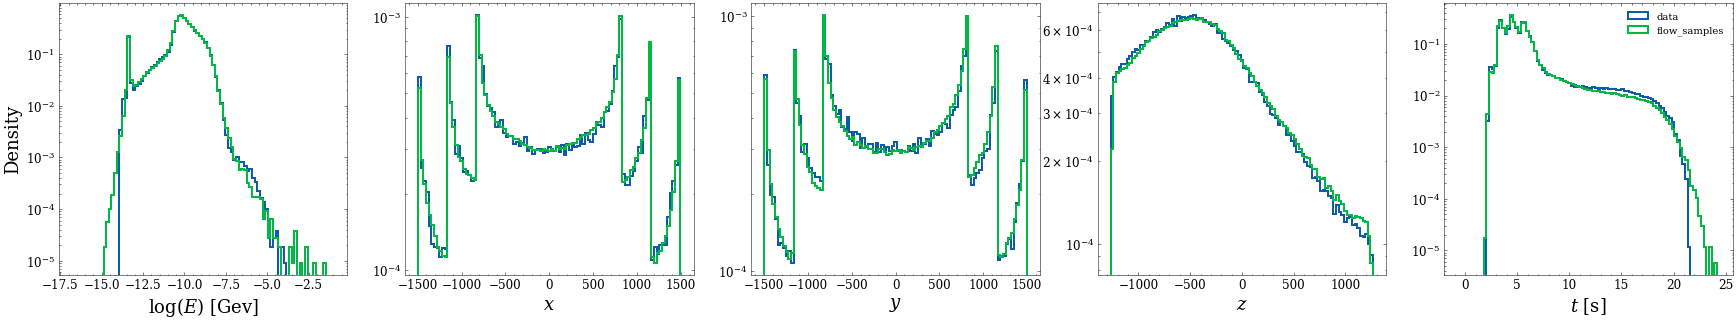

In [14]:

plot_hists_1d({"data":data, **X_samples}, bins_dict, log_dims=log_vars, labels=feature_labels)
plt.savefig(f"{save_dir}/hists_final")

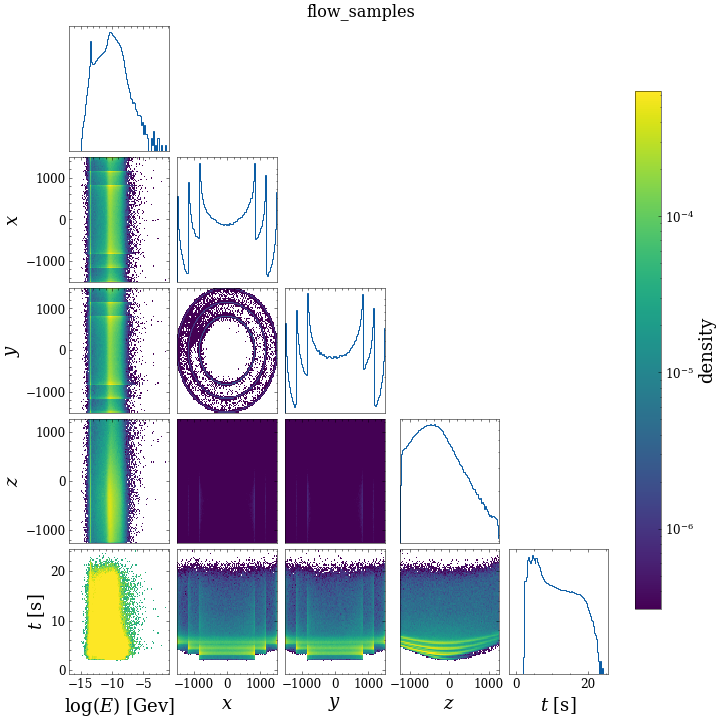

In [15]:
for key in X_samples.keys():
    fig_samp, axes_samp = plot_corner_hist_2d(
        X_samples[key],
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=log_vars,
        title= key,
    )
    plt.savefig(f"{save_dir}/corner_{key}_final")



# Restrict layers

678750
678750


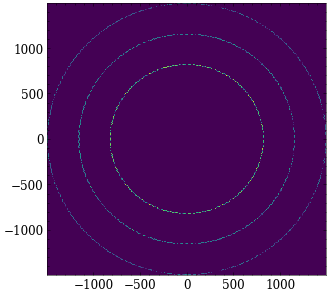

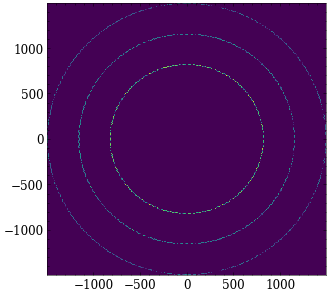

In [16]:




def get_x_y_mask(X, layer_radii=(819, 1153, 1486), thickness=15):
    layer_radii = np.asarray(layer_radii)   # convert list → numpy array
    half_t = thickness / 2

    r = np.sqrt(X[:,1]**2 + X[:,2]**2)

    mask = np.any(
        np.abs(r[:, None] - layer_radii[None, :]) <= half_t,
        axis=1
    )
    return mask


m = get_x_y_mask(data)
print(len(m))
print(sum(m))


plt.figure(figsize = (5,5))
plt.hist2d(data[:,1], data[:,2], bins = 500)
plt.show()


plt.figure(figsize = (5,5))
plt.hist2d(data[m][:,1], data[m][:,2], bins = 500)
plt.show()

678750
530427


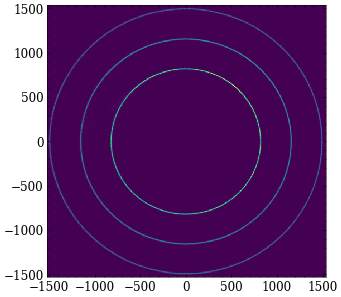

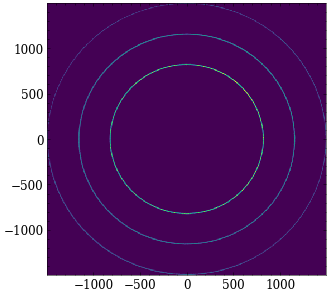

In [17]:
m = get_x_y_mask(X_samples["flow_samples"])
print(len(m))
print(sum(m))


plt.figure(figsize = (5,5))
plt.hist2d(X_samples["flow_samples"][:,1], X_samples["flow_samples"][:,2], bins = 500)
plt.show()


plt.figure(figsize = (5,5))
plt.hist2d(X_samples["flow_samples"][m][:,1], X_samples["flow_samples"][m][:,2], bins = 500)
plt.show()



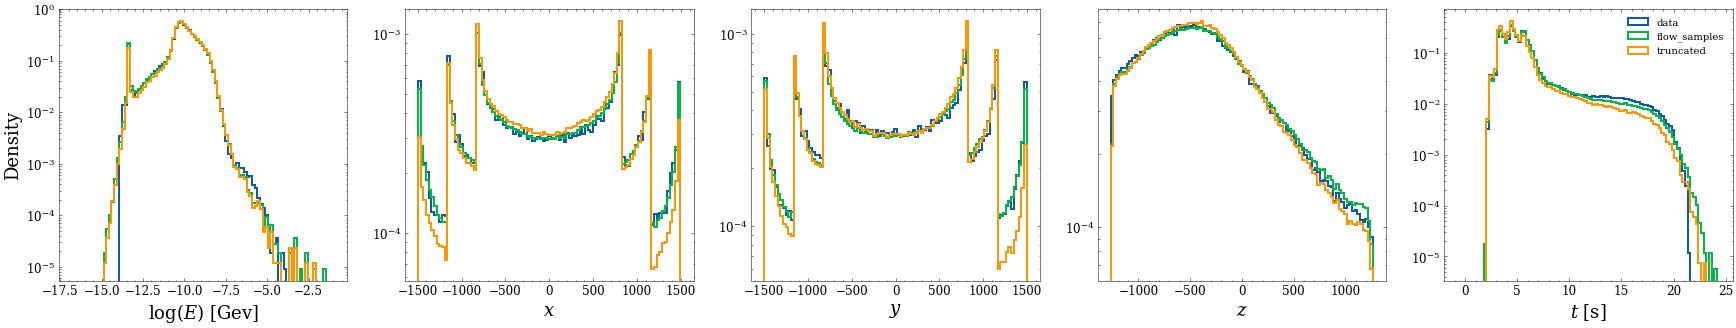

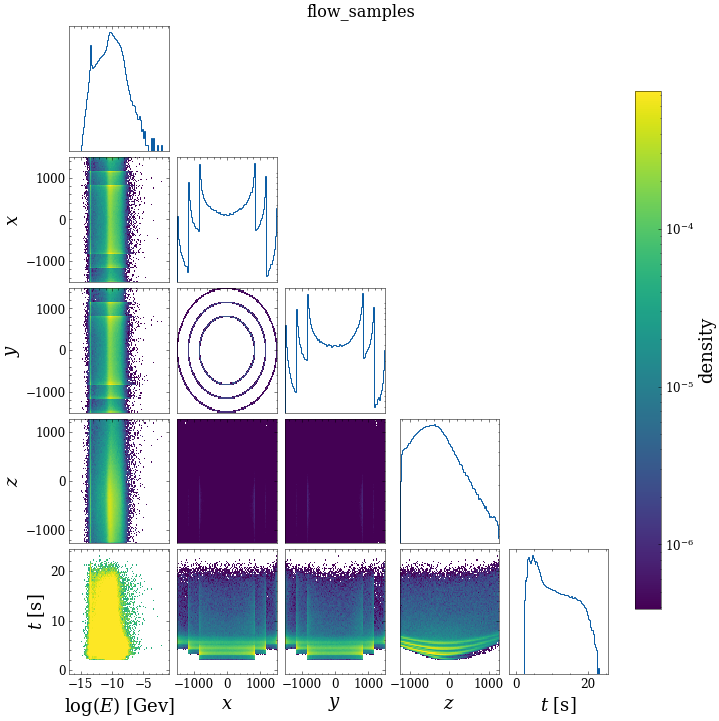

In [18]:

plot_hists_1d({"data":data, **X_samples, "truncated":X_samples["flow_samples"][m]}, bins_dict, log_dims=log_vars, labels=feature_labels)
plt.savefig(f"{save_dir}/hists_final")


fig_samp, axes_samp = plot_corner_hist_2d(
        X_samples[key][m],
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=log_vars,
        title= key,
    )